In [1]:
import os
from collections import defaultdict
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import sympy

from experiments.feynman_dm import FeynmanDataModule, TransformedFeynmanDataModule

In [2]:
run_dirs = {r.stem.split("_")[-1]: r for r in Path("lasr_runs/exp_0.bk").glob("*/run_logs_*.csv")}
transformed_run_dirs = {os.path.basename(r.parent): r for r in Path("lasr_runs/exp_1.bk").glob("*/run_logs_*.csv")}

In [3]:
grouped_run_dirs = defaultdict(list)

for k,v in run_dirs.items():
    grouped_run_dirs[k].append(v)

for k,v in transformed_run_dirs.items():
    grouped_run_dirs[k.split('_')[0]].append(v)

In [ ]:
grouped_run_dirs

defaultdict(list,
            {'I.37.4': [PosixPath('lasr_runs/exp_0.bk/I.37.4/run_logs_I.37.4.csv')],
             'II.6.15a': [PosixPath('lasr_runs/exp_0.bk/II.6.15a/run_logs_II.6.15a.csv')],
             'II.38.14': [PosixPath('lasr_runs/exp_0.bk/II.38.14/run_logs_II.38.14.csv')],
             'I.47.23': [PosixPath('lasr_runs/exp_0.bk/I.47.23/run_logs_I.47.23.csv')],
             'I.15.1': [PosixPath('lasr_runs/exp_0.bk/I.15.1/run_logs_I.15.1.csv')],
             'II.27.18': [PosixPath('lasr_runs/exp_0.bk/II.27.18/run_logs_II.27.18.csv')],
             'III.10.19': [PosixPath('lasr_runs/exp_0.bk/III.10.19/run_logs_III.10.19.csv')],
             'I.12.2': [PosixPath('lasr_runs/exp_0.bk/I.12.2/run_logs_I.12.2.csv'),
              PosixPath('lasr_runs/exp_1.bk/I.12.2_3_0/run_logs_I.12.2_3_0.csv'),
              PosixPath('lasr_runs/exp_1.bk/I.12.2_3_1/run_logs_I.12.2_3_1.csv'),
              PosixPath('lasr_runs/exp_1.bk/I.12.2_0_0/run_logs_I.12.2_0_0.csv'),
              PosixPath('la

In [12]:
# for run_result_csv in run_dirs:
#     df = pd.read_csv(run_result_csv, header = None)
#     df.columns = ['Iteration', 'Complexity', 'Loss', 'Score', 'Expression', 'Time']
#     break

eq_name = "I.11.19"

runs = grouped_run_dirs[eq_name]

dfs = []
for run in runs:
    df = pd.read_csv(run, header = None)
    df.columns = ['Iteration', 'Complexity', 'Loss', 'Score', 'Expression', 'Time']
    selected_id = df.groupby(by="Iteration")['Loss'].idxmin()
    grouped_df = df.loc[selected_id].copy()
    grouped_df['sympy_format'] = grouped_df['Expression'].apply(lambda s: sympy.sympify(s))
    dfs.append(grouped_df)
    # expression = sympy.sympify()

In [20]:
grouped_df['sympy_format'].loc[9]

0.93696*((x₀ + x₁ + x₂**1.5814 + x₃ + x₅)/x₃)**1.0358 + 0.953584106562856

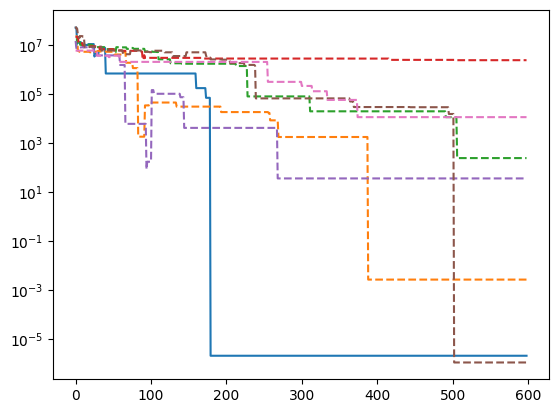

In [22]:
plt.plot(dfs[0]['Loss'].values, linestyle='-')
for i, s in enumerate(dfs[1:]):
    plt.plot(s['Loss'].values, linestyle='--')
plt.yscale("log")